## CW - EW


In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.optimize import minimize
import statsmodels.api as sm



In [9]:
# Load returns from WRDS-derived CSVs
crsp_returns = pd.read_csv("sp500_returns_with_tickers.csv", index_col="date", parse_dates=True)
crsp_caps = pd.read_csv("sp500_market_caps.csv", index_col="date", parse_dates=True)


# Scale market caps (convert to actual $)
crsp_caps = crsp_caps * 1000

# Clean numeric
caps_numeric = crsp_caps.apply(pd.to_numeric, errors='coerce').fillna(0)
rets_numeric = crsp_returns.apply(pd.to_numeric, errors='coerce').fillna(0)

# Align columns
common_cols = caps_numeric.columns.intersection(rets_numeric.columns)
caps_numeric = caps_numeric[common_cols]
rets_numeric = rets_numeric[common_cols]

# Cap-weighted
cap_weights = caps_numeric.div(caps_numeric.sum(axis=1), axis=0)
ret_cap = (rets_numeric * cap_weights).sum(axis=1)

# Equal-weighted
active_mask = caps_numeric > 0
n_active = active_mask.sum(axis=1)
equal_weights = active_mask.div(n_active, axis=0)
ret_eq = (rets_numeric * equal_weights).sum(axis=1)

# Preference Portfolio (CRSP-based)
preference_returns = ret_cap - ret_eq
preference_returns.name = "Preference Portfolio (CW-EW)"




In [10]:
returns_df = pd.DataFrame({
    "Cap-Weighted": ret_cap,
    "Equal-Weighted": ret_eq,
    "Preference Portfolio (CW-EW)": preference_returns
})

# Set rolling window size (e.g., 36 months)
window = 36

# Rolling volatility (annualized)
rolling_vol_1 = returns_df.rolling(window).std() * np.sqrt(12)

# Rolling Sharpe Ratio (assumes risk-free rate ~ 0)
rolling_sharpe_1 = returns_df.rolling(window).mean() / returns_df.rolling(window).std() * np.sqrt(12)

# Cumulative log returns
cumulative_returns_1 = np.log1p(returns_df).cumsum()


In [54]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta),EBC,Preference (Cap - EBC)
date,,,,,,,
1960-01-29,-0.067093,-0.049087,-0.018005,0.000000,-0.067093,0.000000,-0.067093
1960-02-29,0.017111,0.007490,0.009621,0.000000,0.017111,0.000000,0.017111
1960-03-31,-0.010623,-0.025784,0.015161,0.000000,-0.010623,0.000000,-0.010623
1960-04-29,-0.013724,-0.015902,0.002178,0.000000,-0.013724,0.000000,-0.013724
1960-05-31,0.037913,0.025842,0.012071,0.000000,0.037913,0.000000,0.037913
...,...,...,...,...,...,...,...
2024-08-30,0.028116,0.024943,0.003173,0.045284,-0.017168,0.026317,0.001798
2024-09-30,0.025856,0.023297,0.002560,0.009644,0.016212,0.016862,0.008994
2024-10-31,-0.004786,-0.016410,0.011624,-0.028102,0.023316,-0.015225,0.010439


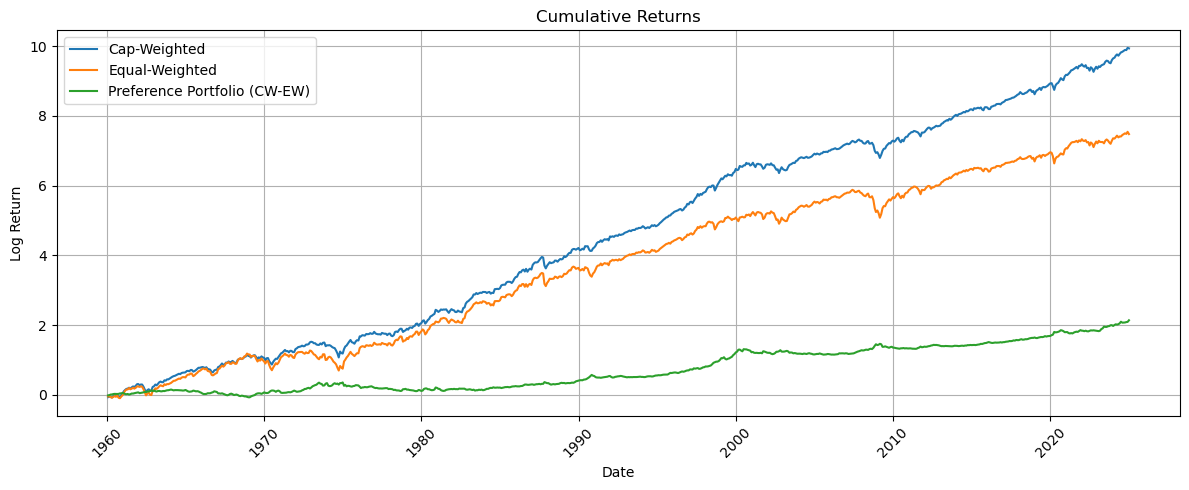

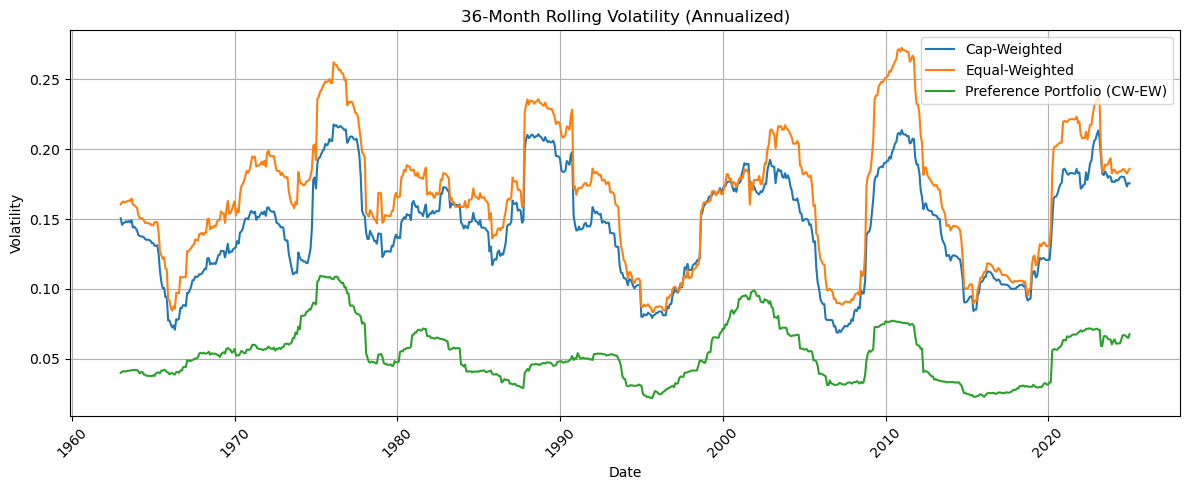

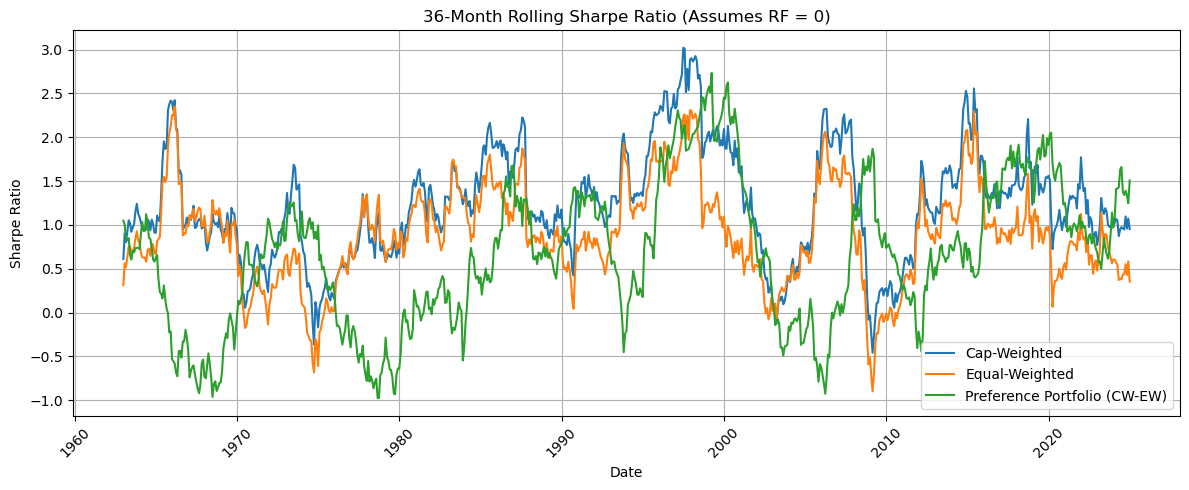

In [12]:
# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns_1)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol_1)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe_1)
plt.title(f"{window}-Month Rolling Sharpe Ratio (Assumes RF = 0)")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe_1.columns)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 1/ β

In [33]:
rets = rets_numeric.copy()
market_ret = ret_cap.copy()
window = 36 

In [34]:
#  Estimate rolling beta for each stock
betas = pd.DataFrame(index=rets.index, columns=rets.columns)

for ticker in rets.columns:
    for i in range(window, len(rets)):
        y = rets[ticker].iloc[i-window:i]
        x = market_ret.iloc[i-window:i]
        if y.isnull().any() or x.isnull().any():
            continue
        x_named = x.rename("x")
        X = sm.add_constant(x_named)
        model = sm.OLS(y, X).fit()
        betas.iloc[i, betas.columns.get_loc(ticker)] = model.params["x"]

betas = betas.astype(float)

# Compute inverse-beta weights
#inv_beta_weights = 1 / betas
inv_beta_weights = 1 / betas.abs()
inv_beta_weights.replace([np.inf, -np.inf], np.nan, inplace=True)
inv_beta_weights = inv_beta_weights.div(inv_beta_weights.sum(axis=1), axis=0)

# Compute 1/Beta portfolio return
one_over_beta_return = (rets * inv_beta_weights).sum(axis=1)
one_over_beta_return.name = "1/Beta Portfolio"

# Compute preference portfolio (Cap - 1/Beta)
ret_pref_invbeta = ret_cap - one_over_beta_return
ret_pref_invbeta.name = "Preference (Cap - 1/Beta)"


In [35]:
returns_df["1/Beta"] = one_over_beta_return
returns_df["Preference (Cap - 1/Beta)"] = ret_pref_invbeta

In [36]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta)
date,,,,,
1960-01-29,-0.067093,-0.049087,-0.018005,0.000000,-0.067093
1960-02-29,0.017111,0.007490,0.009621,0.000000,0.017111
1960-03-31,-0.010623,-0.025784,0.015161,0.000000,-0.010623
1960-04-29,-0.013724,-0.015902,0.002178,0.000000,-0.013724
1960-05-31,0.037913,0.025842,0.012071,0.000000,0.037913
...,...,...,...,...,...
2024-08-30,0.028116,0.024943,0.003173,0.045284,-0.017168
2024-09-30,0.025856,0.023297,0.002560,0.009644,0.016212
2024-10-31,-0.004786,-0.016410,0.011624,-0.028102,0.023316


In [40]:
returns_df[["1/Beta", "Preference (Cap - 1/Beta)"]].to_csv("inverse_beta_returns.csv", index=True)

In [37]:
returns_invb = returns_df[["Cap-Weighted", "1/Beta", "Preference (Cap - 1/Beta)"]]

In [38]:
rolling_vol = returns_invb.rolling(window).std() * np.sqrt(12)
rolling_sharpe = returns_invb.rolling(window).mean() / returns_invb.rolling(window).std() * np.sqrt(12)
cumulative_returns = np.log1p(returns_invb).cumsum()


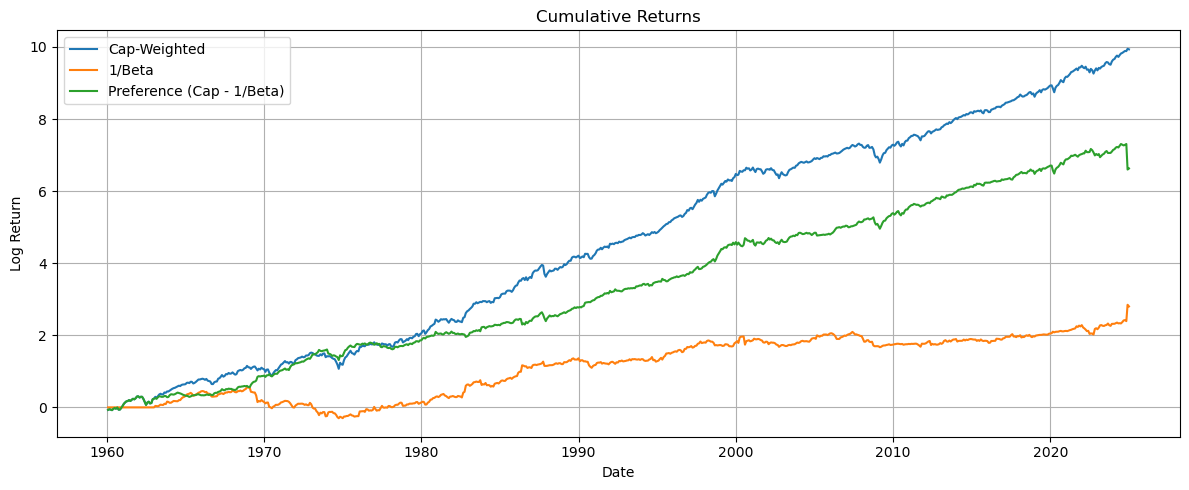

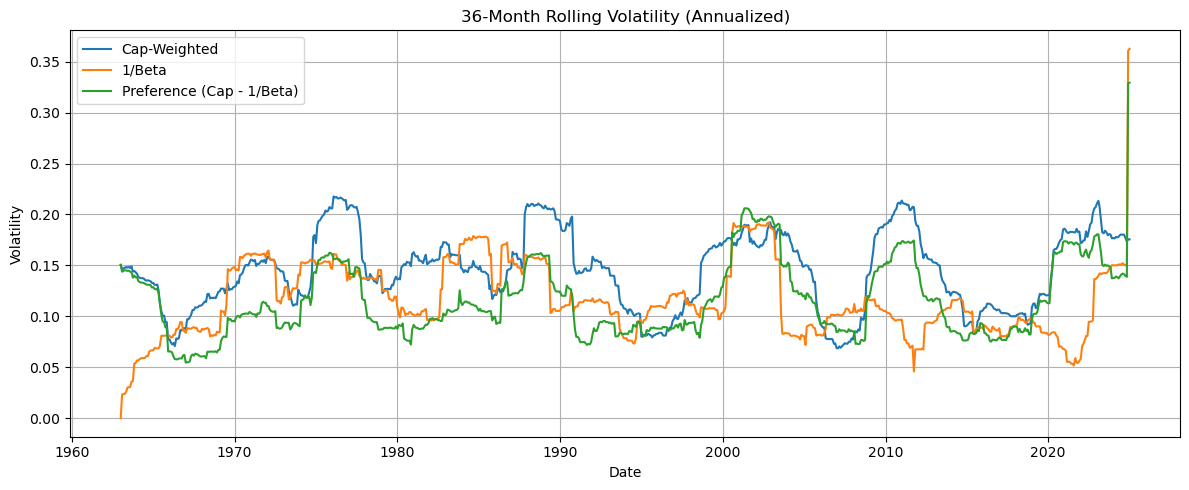

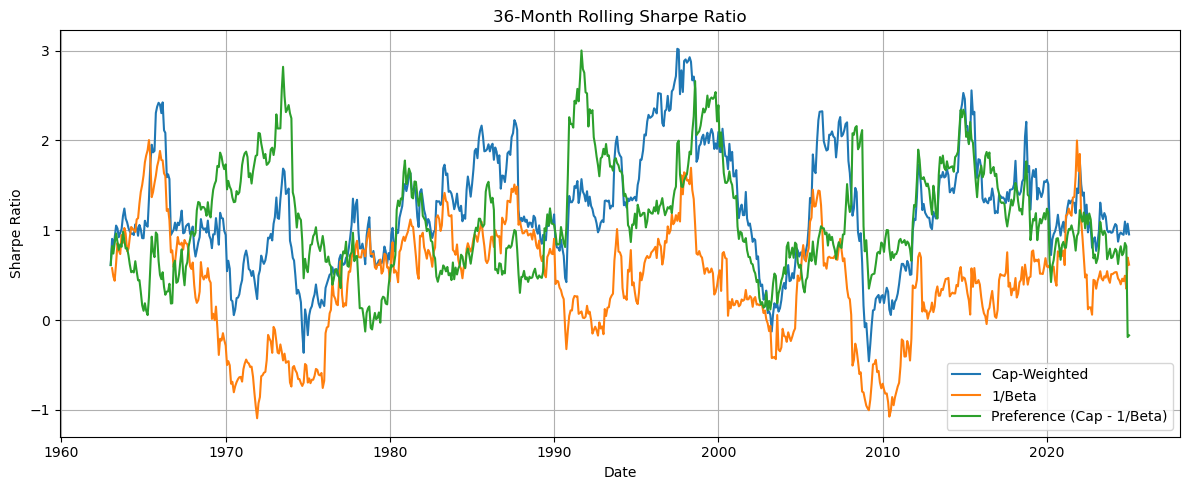

In [39]:
# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe)
plt.title(f"{window}-Month Rolling Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe.columns)
plt.grid(True)
plt.tight_layout()
plt.show()


## EBC

In [41]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def equal_abs_beta_contribution_weights(beta_row):
    #filter out nans and zero betas
    valid_betas = beta_row.dropna()
    valid_betas = valid_betas[valid_betas != 0]

    if valid_betas.empty:
        return pd.Series(dtype=float)

    betas = valid_betas.values
    n = len(betas)
    idx = valid_betas.index

    #objective function to minimize with target of 1/n
    def objective(w):
        contrib = w * betas
        return np.sum((contrib - 1/n)**2)

    #constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]

    #long only weights to mimic equal weight
    bounds = [(0, 1) for _ in range(n)]

    #start with inverted betas
    x0 = 1 / np.abs(betas)
    x0 = x0 / x0.sum()

    result = minimize(objective, x0, bounds=bounds, constraints=constraints)

    if not result.success:
        return pd.Series(dtype=float)

    weights = pd.Series(result.x, index=idx)

    full_weights = pd.Series(0.0, index=beta_row.index)
    full_weights.update(weights)

    return full_weights

In [42]:
rets

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.005155,-0.015000,-0.020785,0.0,-0.092262,0.000000,0.000000,0.0,-0.020833,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-02-29,0.046154,0.017767,0.009434,0.0,-0.021312,0.000000,0.000000,0.0,0.053192,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-03-31,-0.059553,-0.100249,-0.047170,0.0,0.038851,0.000000,0.000000,0.0,-0.005387,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-04-29,-0.081794,-0.056180,0.000000,0.0,-0.050407,0.000000,0.000000,0.0,0.010274,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-05-31,0.048851,-0.029762,-0.034654,0.0,0.029110,0.000000,0.000000,0.0,0.044068,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0.000000,0.000000,0.000000,0.0,0.000000,0.013195,-0.001100,0.0,0.000000,-0.071535,...,0.0,0.013319,0.042292,-0.310823,0.321675,0.0,0.005460,0.0,0.122718,-0.077391
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.206030,0.031548,0.0,0.000000,0.038948,...,0.0,0.062707,-0.016385,0.019284,0.010950,0.0,0.015013,0.0,-0.002580,0.221942
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,-0.012676,-0.055659,0.0,0.000000,0.008538,...,0.0,-0.015826,0.025228,-0.046589,0.014313,0.0,0.041981,0.0,0.042466,-0.045025


In [43]:
from tqdm import tqdm
all_tickers = rets.columns
tqdm.pandas()

equal_abs_beta_weights = betas.progress_apply(
    lambda row: equal_abs_beta_contribution_weights(row).reindex(all_tickers, fill_value=0),
    axis=1
)

100%|██████████| 780/780 [3:13:29<00:00, 14.88s/it]   


In [44]:
# Compute EBC portfolio returns
ebc_return = (equal_abs_beta_weights * rets).sum(axis=1)
ebc_return.name = "EBC Portfolio"

# Preference: Cap-Weighted minus EBC
ret_pref_ebc = ret_cap - ebc_return
ret_pref_ebc.name = "Preference (Cap - EBC)"

# Add to returns_df
returns_df["EBC"] = ebc_return
returns_df["Preference (Cap - EBC)"] = ret_pref_ebc


In [45]:
returns_ebc = returns_df[["Cap-Weighted", "EBC", "Preference (Cap - EBC)"]]

In [46]:
rolling_vol = returns_ebc.rolling(window).std() * np.sqrt(12)
rolling_sharpe = returns_ebc.rolling(window).mean() / returns_ebc.rolling(window).std() * np.sqrt(12)
cumulative_returns = np.log1p(returns_ebc).cumsum()


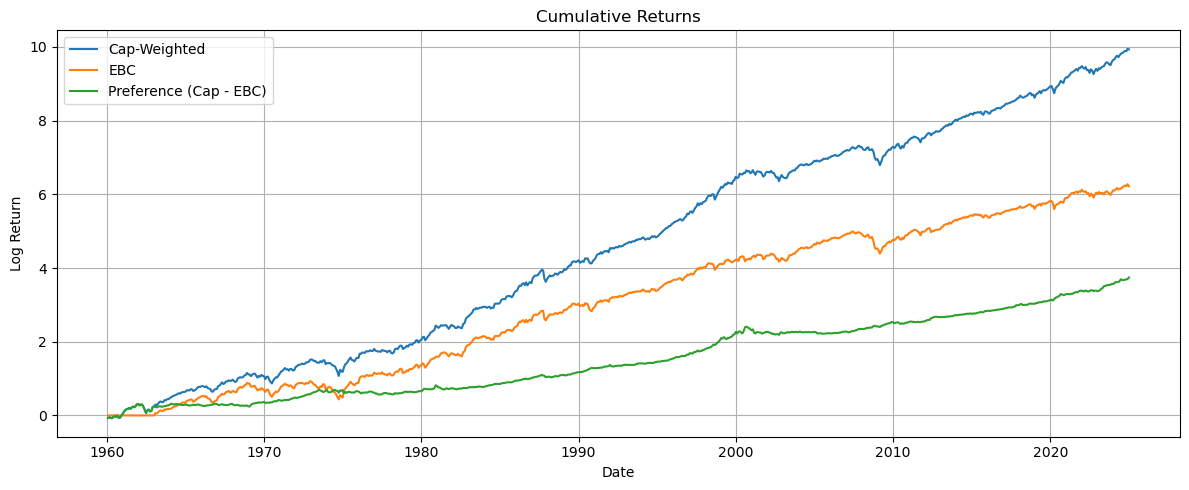

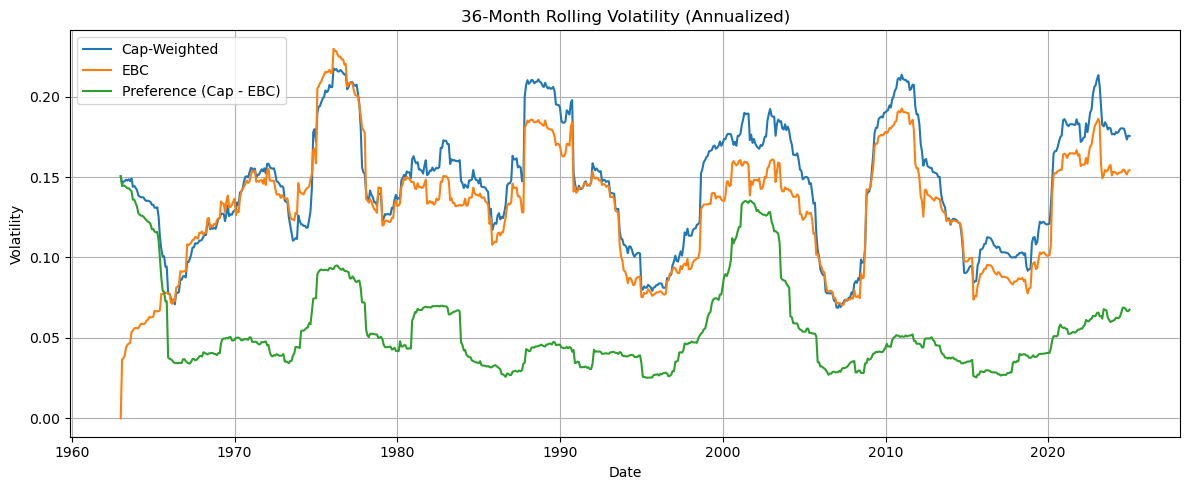

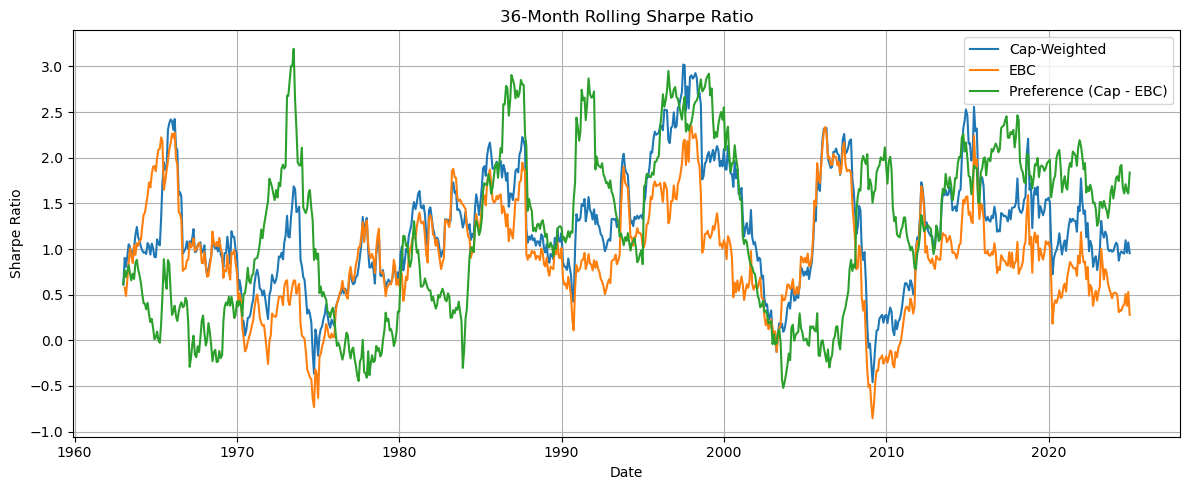

In [47]:

# === Cumulative Returns ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns)
plt.title("Cumulative Returns")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Volatility ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol)
plt.title(f"{window}-Month Rolling Volatility (Annualized)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(rolling_vol.columns)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Rolling Sharpe Ratio ===
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe)
plt.title(f"{window}-Month Rolling Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.legend(rolling_sharpe.columns)
plt.grid(True)
plt.tight_layout()
plt.show()


# PCA

In [48]:
pca_input = returns_df[[
    "Preference Portfolio (CW-EW)",
    "Preference (Cap - 1/Beta)",
    "Preference (Cap - EBC)"
]].dropna()

In [49]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(pca_input)


In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(scaled)

explained_var = pca.explained_variance_ratio_
loadings = pd.DataFrame(pca.components_, columns=pca_input.columns)


In [51]:
pd.Series(explained_var, index=[f"PC{i+1}" for i in range(len(explained_var))])


PC1    0.604077
PC2    0.314082
PC3    0.081841
dtype: float64

In [52]:
loadings = pd.DataFrame(pca.components_, columns=pca_input.columns, index=[f"PC{i+1}" for i in range(3)])
loadings


,Preference Portfolio (CW-EW),Preference (Cap - 1/Beta),Preference (Cap - EBC)
PC1,0.507026,0.511230,0.693951
PC2,0.710502,-0.703695,-0.000710
PC3,-0.487967,-0.493414,0.720022


<Axes: title={'center': 'Principal Components Time Series'}, xlabel='date'>

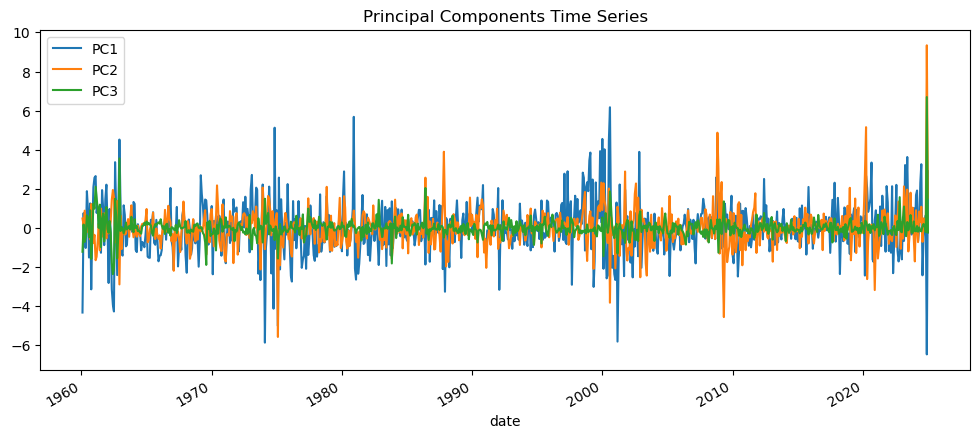

In [53]:
pc_scores = pd.DataFrame(components, index=pca_input.index, columns=[f"PC{i+1}" for i in range(3)])
pc_scores.plot(title="Principal Components Time Series", figsize=(12, 5))


## Asset Pricing

In [87]:
import statsmodels.api as sm

def capm_regression(returns_df, portfolio_col, market_col="Cap-Weighted"):
    y = returns_df[portfolio_col]
    x = returns_df[market_col]
    x = sm.add_constant(x)

    model = sm.OLS(y, x).fit()

    alpha = model.params["const"]
    beta = model.params[market_col]
    alpha_tstat = model.tvalues["const"]
    r_squared = model.rsquared

    alpha_se = model.bse["const"]
    beta_se = model.bse[market_col]
    alpha_pval = model.pvalues["const"]
    beta_pval = model.pvalues[market_col]

    tracking_error = model.resid.std()
    info_ratio = alpha / tracking_error if tracking_error != 0 else float('nan')

    return {
        "alpha": alpha,
        "beta": beta,
        "alpha_tstat": alpha_tstat,
        "r_squared": r_squared,
        "alpha_se": alpha_se,
        "beta_se": beta_se,
        "alpha_pval": alpha_pval,
        "beta_pval": beta_pval,
        "tracking_error": tracking_error,
        "info_ratio": info_ratio,
        "model": model
    }


In [88]:
def print_capm_results(name, results):
    print(f"{name}:")
    print(f"  Alpha             : {results['alpha']*100:.5f}%")
    print(f"  Alpha t-stat      : {results['alpha_tstat']:.2f}")
    print(f"  Alpha SE          : {results['alpha_se']:.5f}")
    print(f"  Alpha p-value     : {results['alpha_pval']:.4f}")
    print(f"  Beta              : {results['beta']:.3f}")
    print(f"  Beta SE           : {results['beta_se']:.5f}")
    print(f"  Beta p-value      : {results['beta_pval']:.4f}")
    print(f"  R²                : {results['r_squared']:.3f}")
    print(f"  Tracking Error    : {results['tracking_error']:.4f}")
    print(f"  Information Ratio : {results['info_ratio']:.3f}")
    print()


In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_capm_scatter(returns_df, portfolio_col, market_col="Cap-Weighted"):
    x = returns_df[market_col]
    y = returns_df[portfolio_col]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(7, 5))
    sns.regplot(x=x, y=y, line_kws={"color": "red"}, scatter_kws={"alpha": 0.4})
    plt.xlabel("Market Return (Cap-Weighted)")
    plt.ylabel(f"{portfolio_col} Return")
    plt.title(f"CAPM Scatter: {portfolio_col} vs Market")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()


In [95]:
def plot_residuals(model, title):
    residuals = model.resid
    plt.figure(figsize=(7, 4))
    plt.plot(residuals, label="Residuals")
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuals Over Time: {title}")
    plt.ylabel("Residual")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [155]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rolling_beta(returns_df, portfolio_col, market_col="Cap-Weighted", window=36):
    subset = returns_df[[portfolio_col, market_col]].dropna().copy()

    betas = []
    dates = []

    for i in range(window, len(subset) + 1):
        window_df = subset.iloc[i - window : i]
        portfolio = window_df[portfolio_col]
        market = window_df[market_col]
        beta = portfolio.cov(market) / market.var()
        betas.append(beta)
        dates.append(window_df.index[-1])

    rolling_beta = pd.Series(betas, index=dates)

    plt.figure(figsize=(10, 4))
    plt.plot(rolling_beta.index, rolling_beta.values, label=f"Rolling Beta: {portfolio_col}")
    plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
    plt.title(f"{portfolio_col} Rolling Beta (window = {window} months)")
    plt.xlabel("Date")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [90]:
results_cw_ew = capm_regression(returns_df, "Preference Portfolio (CW-EW)")
results_ebc = capm_regression(returns_df, "EBC")

print_capm_results("CW–EW:", results_cw_ew)
print_capm_results("EBC:  ", results_ebc)


CW–EW::
  Alpha             : 0.40625%
  Alpha t-stat      : 6.66
  Alpha SE          : 0.00061
  Alpha p-value     : 0.0000
  Beta              : -0.086
  Beta SE           : 0.01354
  Beta p-value      : 0.0000
  R²                : 0.049
  Tracking Error    : 0.0162
  Information Ratio : 0.250

EBC:  :
  Alpha             : -0.24113%
  Alpha t-stat      : -3.82
  Alpha SE          : 0.00063
  Alpha p-value     : 0.0001
  Beta              : 0.813
  Beta SE           : 0.01400
  Beta p-value      : 0.0000
  R²                : 0.813
  Tracking Error    : 0.0168
  Information Ratio : -0.144



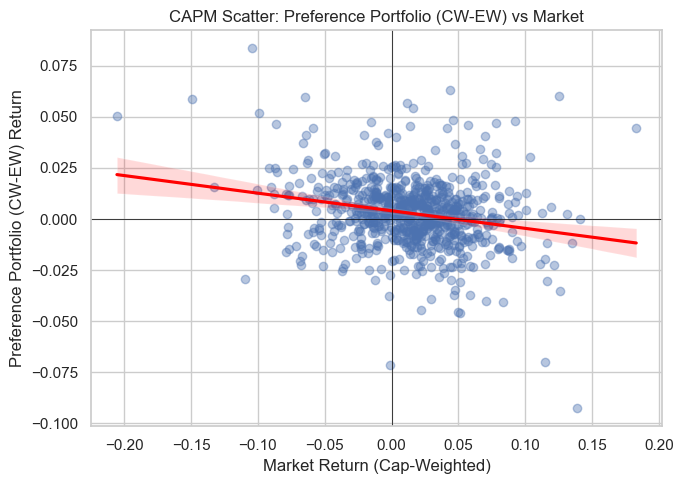

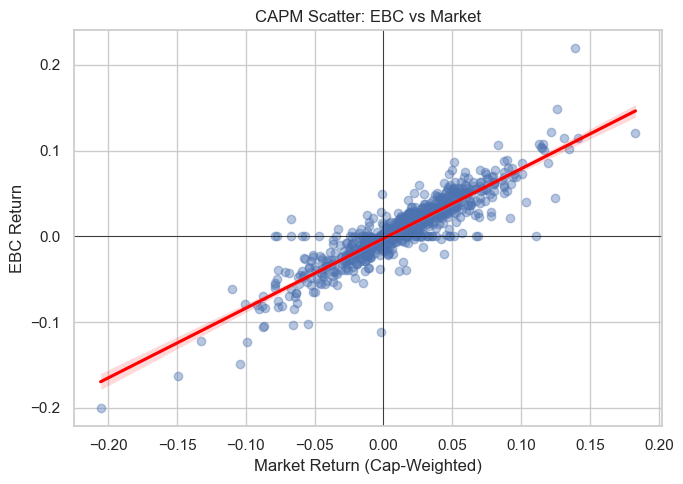

In [94]:
plot_capm_scatter(returns_df, "Preference Portfolio (CW-EW)")
plot_capm_scatter(returns_df, "EBC")


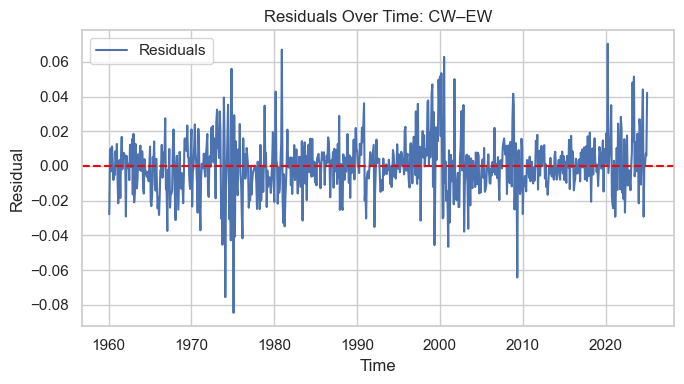

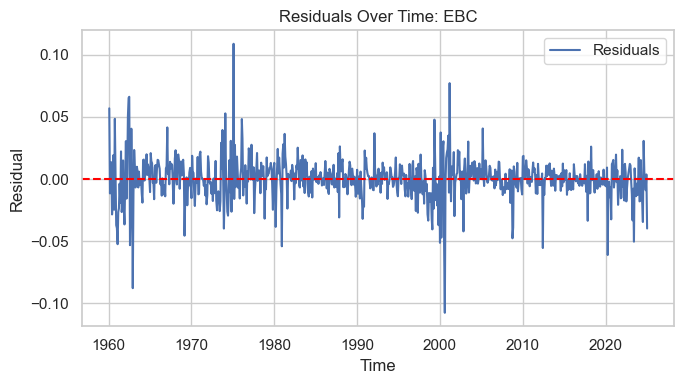

In [97]:
plot_residuals(results_cw_ew["model"], "CW–EW")
plot_residuals(results_ebc["model"], "EBC")


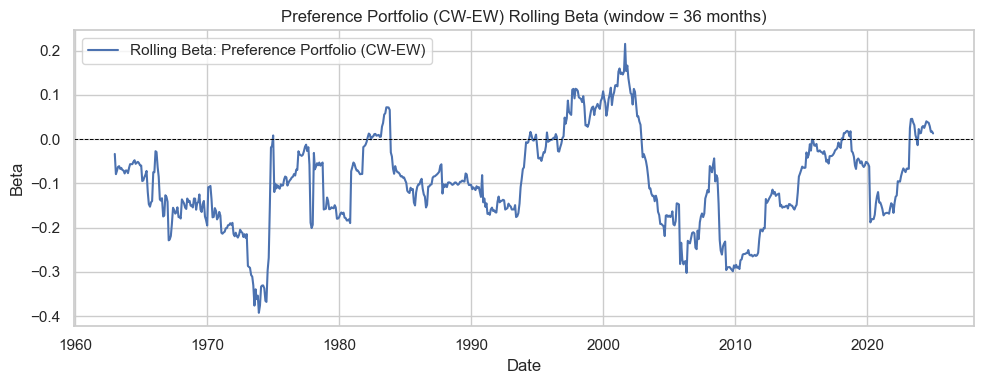

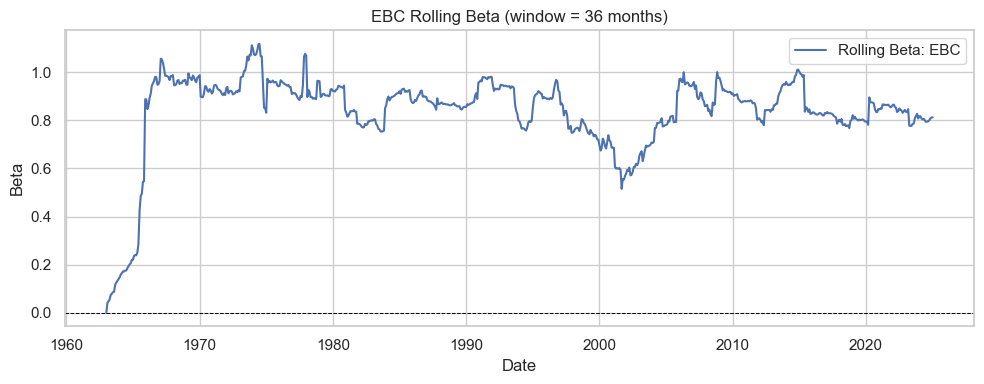

In [156]:
plot_rolling_beta(returns_df, "Preference Portfolio (CW-EW)")
plot_rolling_beta(returns_df, "EBC")


In [109]:
returns_df

,Cap-Weighted,Equal-Weighted,Preference Portfolio (CW-EW),1/Beta,Preference (Cap - 1/Beta),EBC,Preference (Cap - EBC)
date,,,,,,,
1960-01-29,-0.067093,-0.049087,-0.018005,0.000000,-0.067093,0.000000,-0.067093
1960-02-29,0.017111,0.007490,0.009621,0.000000,0.017111,0.000000,0.017111
1960-03-31,-0.010623,-0.025784,0.015161,0.000000,-0.010623,0.000000,-0.010623
1960-04-29,-0.013724,-0.015902,0.002178,0.000000,-0.013724,0.000000,-0.013724
1960-05-31,0.037913,0.025842,0.012071,0.000000,0.037913,0.000000,0.037913
...,...,...,...,...,...,...,...
2024-08-30,0.028116,0.024943,0.003173,0.045284,-0.017168,0.026317,0.001798
2024-09-30,0.025856,0.023297,0.002560,0.009644,0.016212,0.016862,0.008994
2024-10-31,-0.004786,-0.016410,0.011624,-0.028102,0.023316,-0.015225,0.010439
